# Customer Segmentation Analysis (Version 2)

## Project Overview

This project aims to segment airline loyalty program customers into meaningful groups using unsupervised machine learning. Building on insights gained from Version 1, this iteration focuses on improving the quality of the customer segments by selecting features that better represent customer characteristics rather than geographic location.

### Objectives

- Perform data cleaning and preprocessing.
- Engineer a refined feature set for clustering.
- Build and evaluate a K-Means clustering model.
- Profile each customer segment.
- Compare Version 2 against Version 1.
- Prepare the final model for deployment in a Streamlit web application.

In [1]:
import warnings 
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Customer Loyalty History.csv")

In [3]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (16737, 16)


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00


In [6]:
df.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

# Data Cleaning

Before building the clustering model, the dataset is inspected for duplicate records and missing values. Missing data will be handled appropriately to ensure reliable clustering results.

In [7]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [8]:
missing = df.isnull().sum()

missing[missing > 0]

Salary                 4238
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

# Data Cleaning and Feature Selection

The dataset contains a small number of missing values in the **Salary** column and a large number of missing values in the **Cancellation Year** and **Cancellation Month** columns.

The cancellation-related variables are not suitable for clustering because the missing values represent customers who have not cancelled their loyalty membership rather than missing data errors. These columns are therefore excluded from the analysis.

Additionally, geographic variables and unique identifiers are removed to prevent the clustering algorithm from grouping customers primarily by location instead of meaningful customer characteristics.

Version 2 focuses on demographic, loyalty, and customer value attributes to produce more business-oriented customer segments.

In [9]:
# Create a copy of the dataset
df_v2 = df.copy()

# Feature to remove
columns_to_drop = [
    "Loyalty Number",
    "Country",
    "Province",
    "City",
    "Postal Code",
    "Cancellation Year",
    "Cancellation Month"
]

df_v2.drop(columns=columns_to_drop, inplace = True)

print("Dataset Shape After Feature Selection:", df_v2.shape)

df_v2.head()

Dataset Shape After Feature Selection: (16737, 9)


,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2
1,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3
2,Male,College,NaN,Single,Star,3839.75,Standard,2014,7
3,Male,College,NaN,Single,Star,3839.75,Standard,2013,2
4,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10


In [10]:
# Check remaning missing values
df_v2.isnull().sum()

Gender                 0
Education              0
Salary              4238
Marital Status         0
Loyalty Card           0
CLV                    0
Enrollment Type        0
Enrollment Year        0
Enrollment Month       0
dtype: int64

## Missing Value Treatment

After removing unnecessary features, the only remaining missing values are found in the **Salary** column.

Since Salary is a continuous numerical variable and contains potential outliers, the missing values will be imputed using the **median**, which is more robust than the mean and helps preserve the overall distribution of the data.    

In [11]:
# Fill missing Salary values using the median

median_salary = df_v2["Salary"].median()

df_v2["Salary"] = df_v2["Salary"].fillna(median_salary)

print("Remaining Missing Values:")
print(df_v2.isnull().sum())

Remaining Missing Values:
Gender              0
Education           0
Salary              0
Marital Status      0
Loyalty Card        0
CLV                 0
Enrollment Type     0
Enrollment Year     0
Enrollment Month    0
dtype: int64


# Exploratory Data Analysis (Version 2)

The objective of this exploratory analysis is to better understand the selected features before clustering.

Particular attention is given to the numerical variables, as K-Means is sensitive to feature distributions and outliers. The analysis will assess the distribution of Salary, Customer Lifetime Value (CLV), and enrollment information to determine whether additional preprocessing or feature engineering is required.

In [12]:
# Summary statistics for numerical features
df_v2[["Salary", "CLV", "Enrollment Year", "Enrollment Month"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Salary,16737.0,77779.360817,30357.407569,-58486.00,63899.00,73455.00,82940.00,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00


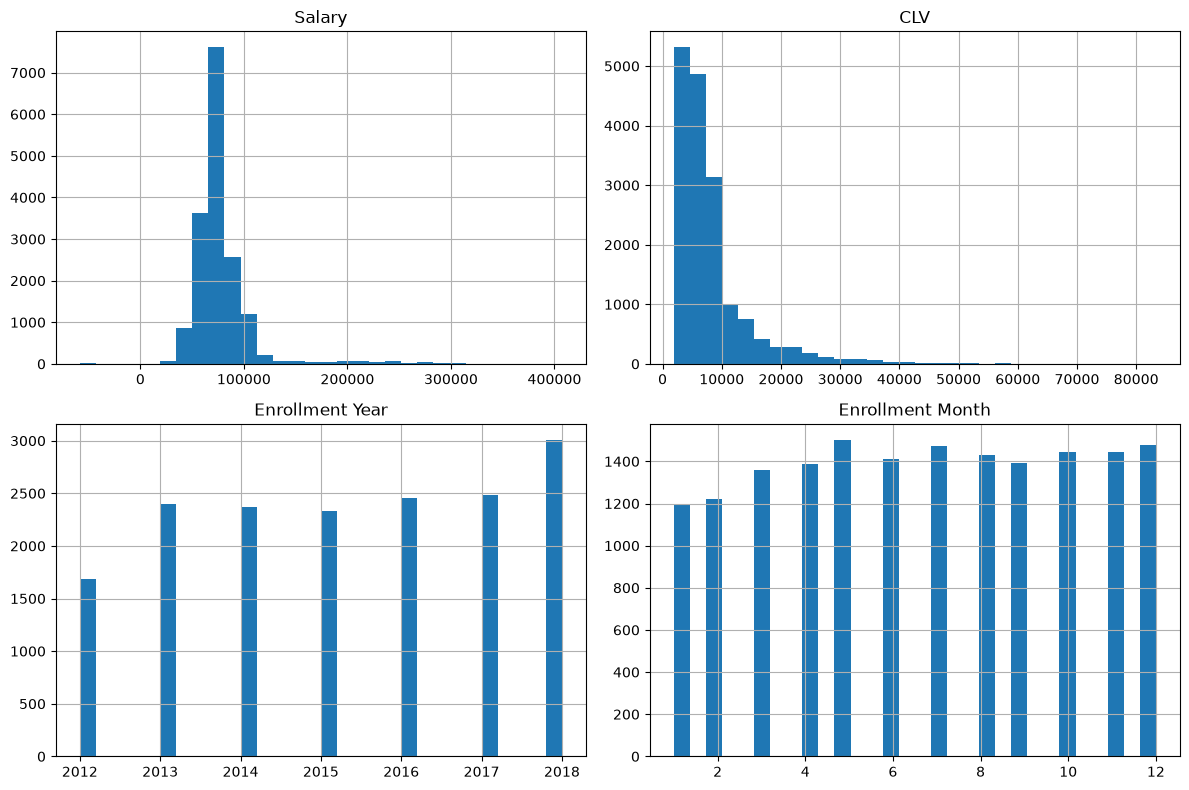

In [13]:
numerical_features = [
    "Salary",
    "CLV",
    "Enrollment Year",
    "Enrollment Month"
]

df_v2[numerical_features].hist(
    figsize = (12, 8),
    bins = 30
)

plt.tight_layout()
plt.show()

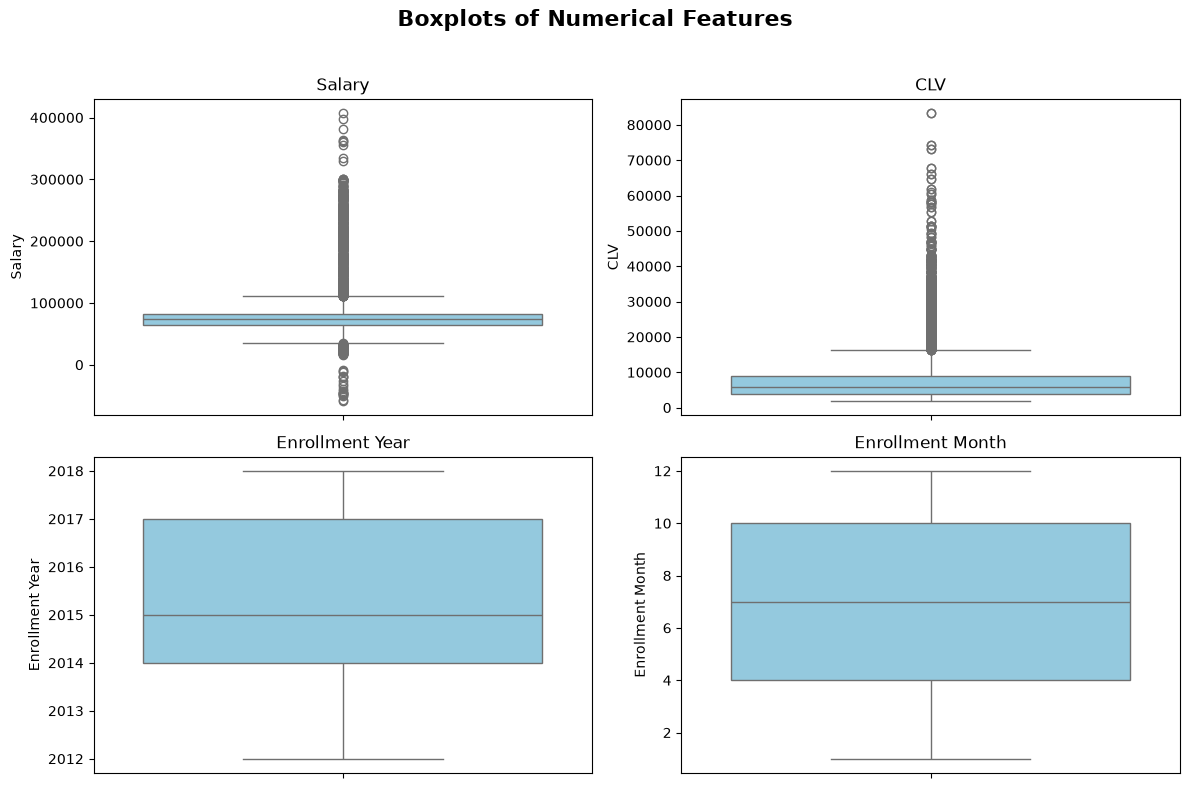

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features
numerical_features = [
    "Salary",
    "CLV",
    "Enrollment Year",
    "Enrollment Month"
]

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each boxplot
for i, feature in enumerate(numerical_features):
    sns.boxplot(
        y=df_v2[feature],
        ax=axes[i],
        color="skyblue"
    )
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feature)

# Improve spacing
plt.suptitle("Boxplots of Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

#### Correlation Matrix

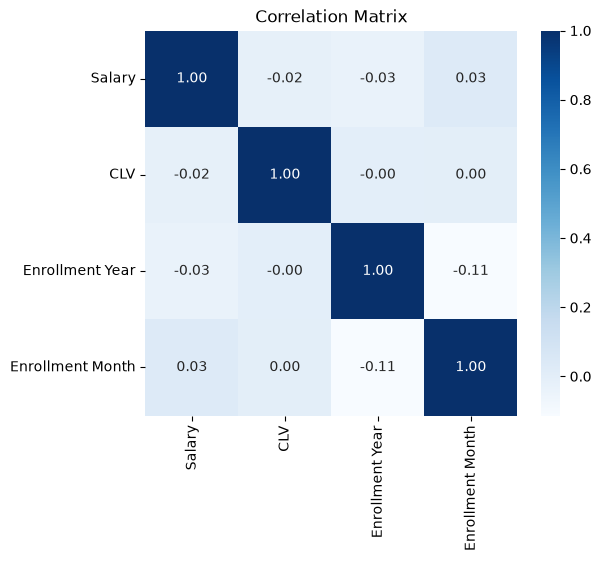

In [15]:
corr = df_v2[numerical_features].corr()

plt.figure(figsize = (6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
categorical_features = [
    "Gender",
    "Education",
    "Marital Status",
    "Loyalty Card",
    "Enrollment Type"
]

df_encoded_v2 = pd.get_dummies(
    df_v2,
    columns=categorical_features,
    drop_first=True
)

print("Dataset shape after encoding:")
print(df_encoded_v2.shape)

df_encoded_v2.head()

Dataset shape after encoding:
(16737, 14)


,Salary,CLV,Enrollment Year,Enrollment Month,Gender_Male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,Loyalty Card_Nova,Loyalty Card_Star,Enrollment Type_Standard
0,83236.0,3839.14,2016,2,False,False,False,False,False,True,False,False,True,True
1,73455.0,3839.61,2016,3,True,True,False,False,False,False,False,False,True,True
2,73455.0,3839.75,2014,7,True,True,False,False,False,False,True,False,True,True
3,73455.0,3839.75,2013,2,True,True,False,False,False,False,True,False,True,True
4,103495.0,3842.79,2014,10,True,False,False,False,False,True,False,False,True,True


## Feature Selection

In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the encoded dataset
scaled_data_v2 = scaler.fit_transform(df_encoded_v2)

# Convert back to a DataFrame
scaled_df_v2 = pd.DataFrame(
    scaled_data_v2,
    columns=df_encoded_v2.columns
)
print("Scaled dataset shape:")
print(scaled_df_v2.shape)

scaled_df_v2.head()

Scaled dataset shape:
(16737, 14)


,Salary,CLV,Enrollment Year,Enrollment Month,Gender_Male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,Loyalty Card_Nova,Loyalty Card_Star,Enrollment Type_Standard
0,0.179752,-0.604852,0.377347,-1.373732,-0.995053,-0.582295,-0.214164,-0.221388,-0.176924,0.848092,-0.604939,-0.715871,1.091589,0.24817
1,-0.142453,-0.604784,0.377347,-1.079515,1.004971,1.717343,-0.214164,-0.221388,-0.176924,-1.179117,-0.604939,-0.715871,1.091589,0.24817
2,-0.142453,-0.604763,-0.633238,0.097351,1.004971,1.717343,-0.214164,-0.221388,-0.176924,-1.179117,1.653059,-0.715871,1.091589,0.24817
3,-0.142453,-0.604763,-1.138531,-1.373732,1.004971,1.717343,-0.214164,-0.221388,-0.176924,-1.179117,1.653059,-0.715871,1.091589,0.24817
4,0.847121,-0.604320,-0.633238,0.980001,1.004971,-0.582295,-0.214164,-0.221388,-0.176924,0.848092,-0.604939,-0.715871,1.091589,0.24817


In [18]:
print("Missing Values after Scaling:")
print(scaled_df_v2.isnull().sum().sum())

print("\nMean of scaled features (first 10):")
print(scaled_df_v2.mean().head(10))

print("\nStandard deviation of scaled features (first 10):")
print(scaled_df_v2.std().head(10))

Missing Values after Scaling:
0

Mean of scaled features (first 10):
Salary                           -7.960015e-17
CLV                               3.396273e-17
Enrollment Year                  -1.442142e-14
Enrollment Month                 -1.952857e-17
Gender_Male                       2.334938e-17
Education_College                 8.490682e-17
Education_Doctor                  5.518943e-17
Education_High School or Below    2.801925e-17
Education_Master                 -1.698136e-18
Marital Status_Married           -1.018882e-16
dtype: float64

Standard deviation of scaled features (first 10):
Salary                            1.00003
CLV                               1.00003
Enrollment Year                   1.00003
Enrollment Month                  1.00003
Gender_Male                       1.00003
Education_College                 1.00003
Education_Doctor                  1.00003
Education_High School or Below    1.00003
Education_Master                  1.00003
Marital Status_Ma

## Finding the Optimal Number of Clusters (Elbow Method)

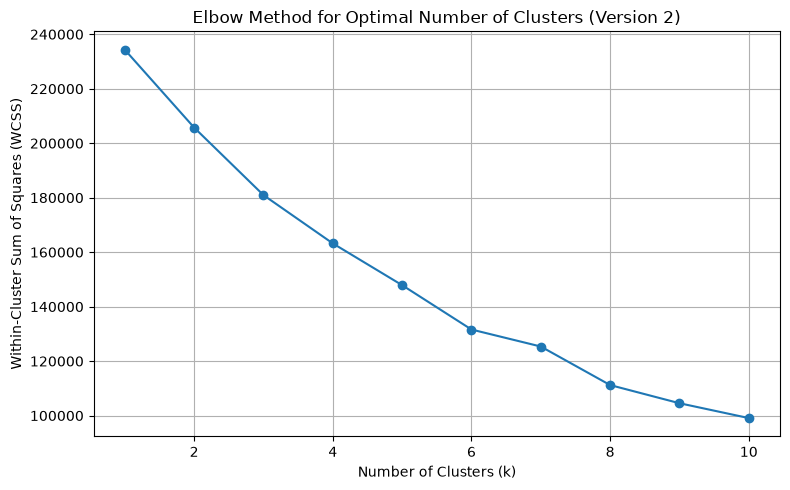

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Compute WCSS for different values of k
wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_df_v2)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize = (8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters (Version 2)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_df_v2)

    score = silhouette_score(scaled_df_v2, labels)
    silhouette_scores.append(score)

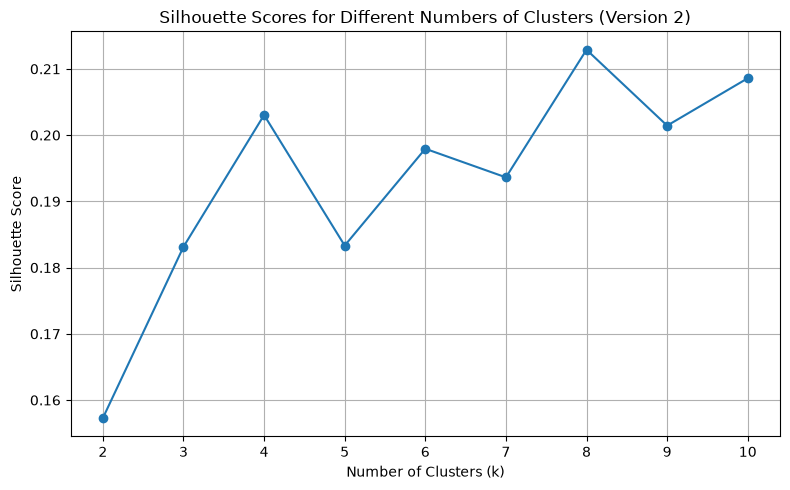

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different Numbers of Clusters (Version 2)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}: {score:.4f}")

k = 2: 0.1573
k = 3: 0.1831
k = 4: 0.2030
k = 5: 0.1833
k = 6: 0.1979
k = 7: 0.1936
k = 8: 0.2129
k = 9: 0.2014
k = 10: 0.2086


In [23]:
kmeans_v2 = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

clusters_v2 = kmeans_v2.fit_predict(scaled_df_v2)

df_v2["Cluster"] = clusters_v2

print("Cluster counts:")
print(df_v2["Cluster"].value_counts().sort_index())

Cluster counts:
Cluster
0    2173
1    6197
2    2083
3    3390
4     870
5     782
6     734
7     508
Name: count, dtype: int64


In [24]:
cluster_profile = df_v2.groupby("Cluster")[[
    "Salary",
    "CLV",
    "Enrollment Year",
    "Enrollment Month"
]].mean().round(2)

cluster_profile

,Salary,CLV,Enrollment Year,Enrollment Month
Cluster,,,,
0,72973.27,9208.79,2015.10,6.94
1,73280.64,8165.45,2015.08,6.86
2,73202.00,6356.70,2015.08,6.80
3,73402.35,8018.49,2015.12,6.93
4,64623.46,8181.98,2018.00,3.04
5,61071.72,7707.08,2015.20,6.62
6,178608.90,7832.92,2015.08,6.92
7,103757.85,7440.62,2015.24,6.82


In [25]:
df_v2.groupby("Cluster").agg({
    "Gender": lambda x: x.mode()[0],
    "Education": lambda x: x.mode()[0],
    "Marital Status": lambda x: x.mode()[0],
    "Loyalty Card": lambda x: x.mode()[0],
    "Enrollment Type": lambda x: x.mode()[0]
})

,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
Cluster,,,,,
0,Female,College,Single,Nova,Standard
1,Male,Bachelor,Married,Star,Standard
2,Male,College,Single,Star,Standard
3,Female,Bachelor,Married,Nova,Standard
4,Female,Bachelor,Married,Star,2018 Promotion
5,Female,High School or Below,Married,Star,Standard
6,Female,Doctor,Married,Star,Standard
7,Female,Master,Married,Star,Standard


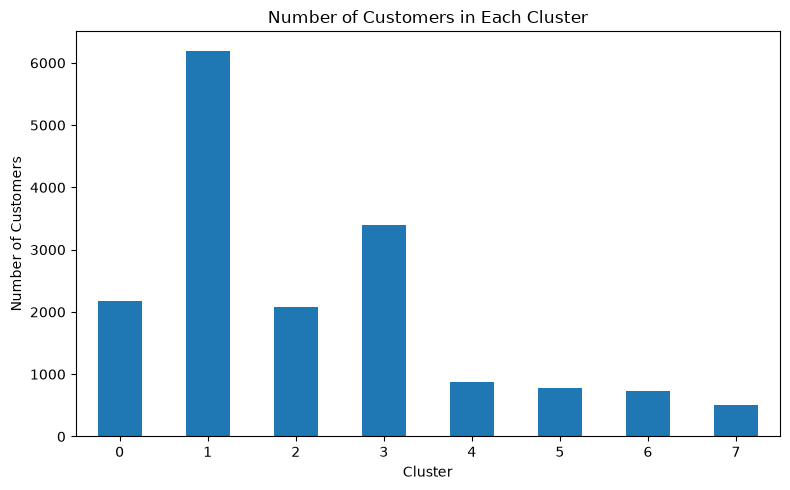

In [26]:
cluster_counts = df_v2["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(scaled_df_v2)

pca_df = pd.DataFrame({
    "PC1": pca_components[:,0],
    "PC2": pca_components[:,1],
    "Cluster": df_v2["Cluster"]
})

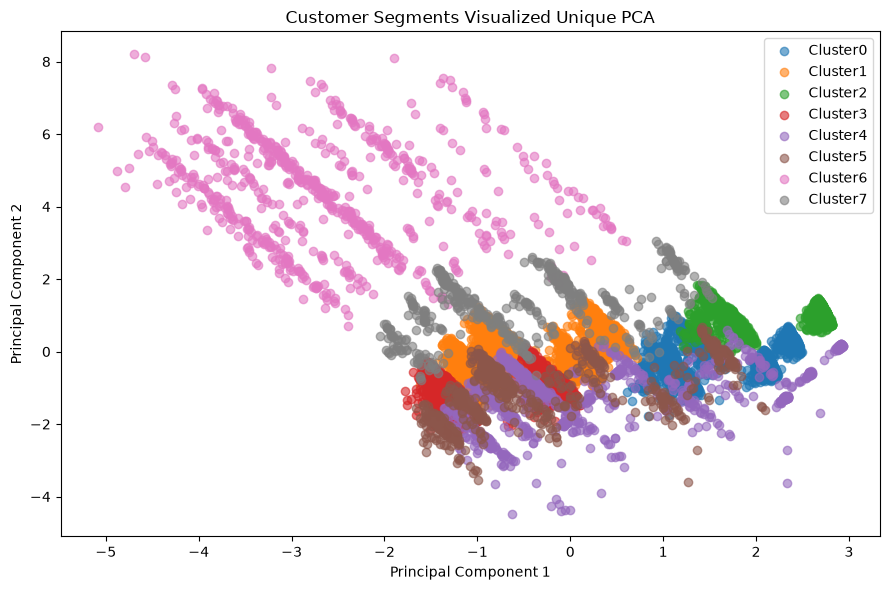

In [28]:
plt.figure(figsize=(9,6))

for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"]==cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster{cluster}",
        alpha=0.6
    )

plt.title("Customer Segments Visualized Unique PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(f"\nTotal Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

Explained Variance Ratio:
[0.14617777 0.12455029]

Total Variance Explained: 27.07%


In [30]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(df_encoded_v2.columns.tolist(), "feature_columns.pkl")

print("Model, scaler, and feature columns saved successfully.")

Model, scaler, and feature columns saved successfully.


In [1]:
import sys
print(sys.executable)

C:\Users\sanob\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
import sklearn
print(sklearn.__version__)

1.9.0
